Building a basic chatbot, but later on adding:
- chatting feature
- RAG
- Tools
- UI
- LangSmith Integration

And studying concept of:
- Memory
- Persistence
- HITL
- Retry (Fault Tolerance)

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model="gpt-4.1-nano")

In [4]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

# BaseMessage is the parent class for all message types in langchain_core, such as HumanMessage, SystemMessage, AIMessage etc. By using BaseMessage, we can have a list of messages that can contain any type of message. 

# we wanna keep adding messages as history for LLM, so we can use operator.add, but add_messages is more optimized to handle messages

In [5]:
def chat_node(state: ChatState):

    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

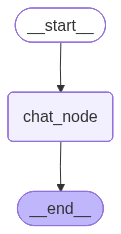

In [6]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()
chatbot

In [7]:
initial_state = {
    "messages": [HumanMessage(content="Hello, my name is Suryam")]
}
result = chatbot.invoke(initial_state)
print(result)

{'messages': [HumanMessage(content='Hello, my name is Suryam', additional_kwargs={}, response_metadata={}, id='6972de12-3618-4159-9d9f-e73119922ccd'), AIMessage(content='Hello, Suryam! Nice to meet you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 15, 'total_tokens': 33, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_a65955873c', 'id': 'chatcmpl-DYEUMU7lo9G2Vm34D17XyEUDpZb0w', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dc081-b2cc-7f61-84d6-413ccc11585c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 18, 'total_tokens': 33, 'input_token_details': {'aud

In [18]:
result['messages'][-1].content

"Hello, Suryam! It's great to meet you. How can I assist you today?"

In [8]:
while True:

    user_message = input('Type here: ')

    print("User:", user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        print("Goodbye!")
        break

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]})

    print('AI:', response['messages'][-1].content)

User: hi
AI: Hello! How can I assist you today?
User: how are you
AI: I'm doing well, thank you! How can I assist you today?
User: wasup
AI: Hey! Not much, just here to help. How about you?
User: whats 4*5
AI: 4 multiplied by 5 equals 20.
User: 
AI: Hello! It seems like your message didn't include a request or question. How can I assist you today?
User: exit
Goodbye!


In [21]:
while True:

    user_message = input('Type here: ')

    print("User:", user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        print("Goodbye!")
        break

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]})

    print('AI:', response['messages'][-1].content)

User: my name is suryam
AI: Hello, Suryam! How can I assist you today?
User: whats my name
AI: I'm sorry, but I don't know your name. How can I assist you today?
User: qhat is 5+10
AI: 5 + 10 equals 15.
User: add 20 to the result
AI: Sure! Please specify the initial value or the result you'd like me to add 20 to.
User: exit
Goodbye!


### Memory Issue

This doesn't have memory, even though we are appending messages in the code, because:

We get user input, it goes into chat_node, it answers, and then the chatbot workflow reaches END and that's it, task is done there's nothing in the state anymore.

The main issue is: every time we call chatbot.invoke(), it results in reaching the END node and ending everyhting. When we continue chatting, a brand new dict with only the current message is passed. The add_messages reducer only accumulates messages within a single invoke() call — once that call ends and the graph hits END, the state is discarded.

So the main main problem is calling invoke() every time.

In [9]:
while True:
    initial_state = input('Type here: ')
    print("User:", initial_state)
    if initial_state.strip().lower() in ['exit', 'quit', 'bye']:
        print("Goodbye!")
        break
    final_state = chatbot.invoke({'messages': [HumanMessage(content=initial_state)]})
    print('AI:', final_state['messages'][-1].content)
    print('-'*50)
    print(final_state)
    print('-'*50)

User: hi
AI: Hello! How can I assist you today?
--------------------------------------------------
{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='b5bf86ea-29da-449e-957f-341190cd11c4'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_4049f081d2', 'id': 'chatcmpl-DYEVLpe02VONnr3YKRJkJgnkq2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dc082-a02a-77b1-a372-42e68582c3bb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, '

Notice how every message is only the current message.

### Manual workaround:

To actually accumulate messages, you'd need to maintain a history list yourself outside the loop and pass the full history on each invoke:

In [11]:
history = []
while True:
    user_message = input('Type here: ')
    print("User:", user_message)
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    history.append(HumanMessage(content=user_message))
    response = chatbot.invoke({'messages': history})
    ai_msg = response['messages'][-1]
    history.append(ai_msg)  # add AI reply to history too
    print('AI:', ai_msg.content)

User: hi
AI: Hello! How can I assist you today?
User: my name is suryam
AI: Hi Suryam! Nice to meet you. How can I help you today?
User: what is my name
AI: Your name is Suryam. Nice to meet you again! How can I assist you today?
User: bye


### We have done this before, but in LangGraph, the proper way is to use **persistence** (a checkpointer).

So with persistence, once you reach END node, the state doesnt get deleted or reset, but we store it in a database or in memory (RAM). In industry production level project, db is used, but here we use memory only. 

Coding it all again.

In [ ]:
from langgraph.checkpoint.memory import MemorySaver # for persistence (note: MemorySaver is an old thing, new is InMemorySaver, it will work for now but might get deprecated later)

In [19]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
load_dotenv()

True

In [20]:
llm = ChatOpenAI(model="gpt-4.1-nano")

In [21]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

def chat_node(state: ChatState):

    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

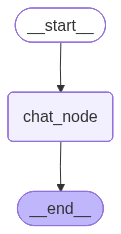

In [22]:
checkpointer = MemorySaver()  # instantiating an object

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)  # we add this while compiling
chatbot

In [23]:
thread_id = '1'  # thread_id like the left panel on chatgpt web interface

while True:

    user_message = input('Type here: ')

    print("User:", user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        print("Goodbye!")
        break

    config = {'configurable': {'thread_id': thread_id}} # you do this

    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config) # and this while invoking

    print('AI:', response['messages'][-1].content)

User: hi
AI: Hello! How can I assist you today?
User: my name is suryam
AI: Hi Suryam! Nice to meet you. How can I help you today?
User: what is my name
AI: Your name is Suryam. Nice to meet you!
User: what is 5+10
AI: 5 + 10 equals 15.
User: add 20 the result
AI: The result after adding 20 to 15 is 35.
User: thankd
AI: You're welcome! If you have any more questions, feel free to ask. Have a great day!
User: bye
Goodbye!


In [26]:
thread_id = '2'
while True:
    initial_state = input('Type here: ')
    print("User:", initial_state)
    if initial_state.strip().lower() in ['exit', 'quit', 'bye']:
        print("Goodbye!")
        break
    config = {'configurable': {'thread_id': thread_id}} 
    final_state = chatbot.invoke({'messages': [HumanMessage(content=initial_state)]}, config=config)
    print('AI:', final_state['messages'][-1].content)
    print('-'*50)
    print(final_state)
    print('-'*50)

User: hi
AI: Hello! How can I assist you today?
--------------------------------------------------
{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='2ce27e18-52e2-49e8-b22b-84279d6ea5c1'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_4049f081d2', 'id': 'chatcmpl-DYO5V1ZodCpyHU3UezohecMtlrOZk', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dc2b4-b834-7f72-839b-d48c833f19af-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, '

It's all adding up now!

In [27]:
chatbot.get_state(config={'configurable': {'thread_id': 1}} )

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='b057c2f6-e40a-458d-8255-a1ab1353bad2'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_4049f081d2', 'id': 'chatcmpl-DYO3gfdm1i4KnVNVjXQJf8j11cTyv', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dc2b2-fec9-7e91-b7bb-cc83839c8ea9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp

In [28]:
chatbot.get_state(config={'configurable': {'thread_id': 2}} )

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='2ce27e18-52e2-49e8-b22b-84279d6ea5c1'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_4049f081d2', 'id': 'chatcmpl-DYO5V1ZodCpyHU3UezohecMtlrOZk', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dc2b4-b834-7f72-839b-d48c833f19af-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp